# Whitmore Diagnostics Notebook

This notebook is intentionally lightweight: it loads the pipeline outputs from `taa_project/outputs/` rather than rerunning the expensive backtests.

In [1]:
from pathlib import Path
import sys
import json
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

REPO_ROOT = Path('/Users/scottthomasswitzer/Desktop/FIN496FP/FIN496-Foundation-Project')
OUTPUT_DIR = Path('/Users/scottthomasswitzer/Desktop/FIN496FP/FIN496-Foundation-Project/taa_project/outputs')
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))
plt.style.use('default')
pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 160)


## Data Profile

In [2]:
inceptions = pd.read_csv(OUTPUT_DIR / 'asset_inception_dates.csv')
gap_summary = pd.read_csv(OUTPUT_DIR / 'asset_gap_summary.csv')
gap_detail = pd.read_csv(OUTPUT_DIR / 'asset_gap_detail.csv')
display(inceptions)
display(gap_summary.head(15))


,asset,first_valid_date,last_valid_date,observation_count,currency,asset_class,sub_category
0,USDJPY,1976-01-01,2026-03-19,13095,JPY,FX,G10 Currency (Inverse)
1,XAU,1976-01-02,2026-03-19,12892,USD,Commodities,Precious Metals
2,COFFEE_FUT,1979-12-31,2026-04-14,11471,USD,Commodities,Softs
3,COTTON_FUT,1979-12-31,2026-04-15,11646,USD,Commodities,Softs
4,SILVER_FUT,1979-12-31,2026-04-15,11929,USD,Commodities,Precious Metals
5,SOYBEAN_FUT,1979-12-31,2026-04-15,11671,USD,Commodities,Grains
6,WHEAT_SPOT,1979-12-31,2026-04-14,11673,USD,Commodities,Grains (Index)
7,NIKKEI225,1980-12-26,2026-04-14,11129,USD,Equities,Developed Market Index
8,AUD,1980-12-31,2026-04-15,11788,USD,FX,G10 Currency
9,CAD,1980-12-31,2026-04-15,11816,USD,FX,G10 Currency


,asset,gap_count,missing_calendar_days,longest_gap_days,extended_gap_count_gt4d
0,TA-125_ISRAEL,1908,4104,6,116
1,CSI300_CHINA,1240,2980,17,95
2,NIKKEI225,2532,5417,11,84
3,COPPERSPOT,2113,4516,6,80
4,FTSE100,2237,4747,5,75
5,CNY,2353,5005,11,60
6,COFFEE_FUT,2471,5436,45,52
7,XAU,2638,5448,7,44
8,LBEATREU_EUROBONDAGG,1467,3078,5,40
9,BCEE1T_EUROAREA,1411,2990,13,29


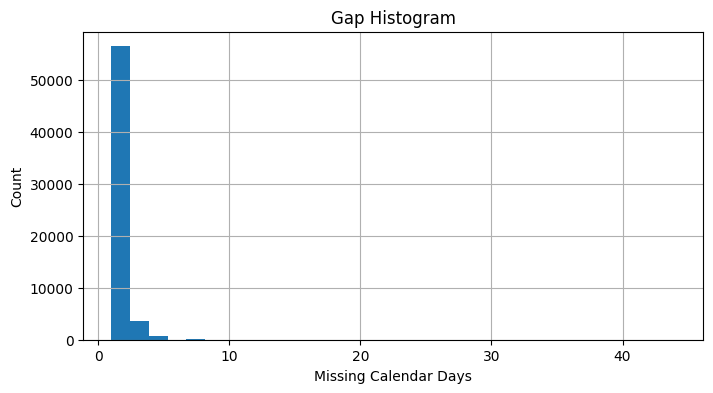

In [3]:
if not gap_detail.empty:
    plt.figure(figsize=(8, 4))
    gap_detail['missing_calendar_days'].hist(bins=30)
    plt.title('Gap Histogram')
    plt.xlabel('Missing Calendar Days')
    plt.ylabel('Count')
    plt.show()
else:
    print('No gap detail rows to plot.')


## SAA Method Comparison

,method,annualized_return,annualized_volatility,max_drawdown,sharpe,sortino,calmar,turnover_pa,cost_drag_pa,start_date,end_date
0,minimum_variance,0.061811,0.074371,-0.300229,0.562193,0.801721,0.205879,0.138650,0.000069,2000-01-04,2025-12-31
1,mean_variance,0.138571,0.233093,-0.769303,0.508683,0.817491,0.180125,0.527677,0.000264,2000-01-04,2025-12-31
2,maximum_diversification,0.117242,0.192542,-0.752191,0.505045,0.802470,0.155868,0.222880,0.000111,2000-01-04,2025-12-31
3,inverse_vol,0.078084,0.118602,-0.497007,0.489743,0.729259,0.157109,0.130533,0.000065,2000-01-04,2025-12-31
4,risk_parity,0.088334,0.144251,-0.617916,0.473714,0.714989,0.142954,0.191534,0.000096,2000-01-04,2025-12-31


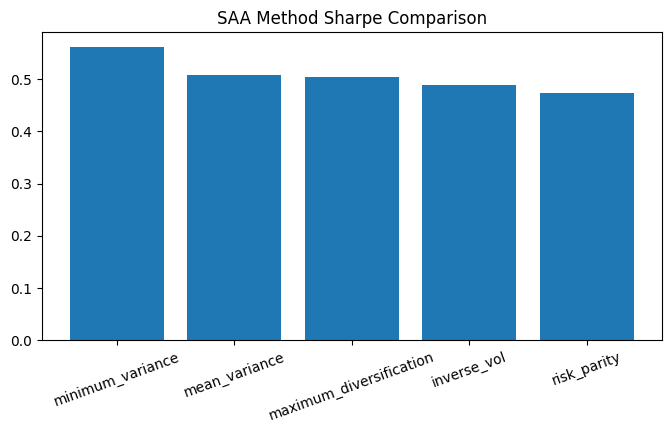

In [4]:
saa_methods = pd.read_csv(OUTPUT_DIR / 'saa_method_comparison.csv')
display(saa_methods)
plt.figure(figsize=(8, 4))
plt.bar(saa_methods['method'], saa_methods['sharpe'])
plt.title('SAA Method Sharpe Comparison')
plt.xticks(rotation=20)
plt.show()


## Signal Diagnostics

In [5]:
oos_regimes = pd.read_csv(OUTPUT_DIR / 'oos_regimes.csv', parse_dates=['date'])
display(oos_regimes['regime'].value_counts(dropna=False).rename_axis('regime').reset_index(name='count'))


,regime,count
0,risk_on,133
1,neutral,73
2,stress,70


In [6]:
from taa_project.data_loader import load_prices
from taa_project.signals.trend_faber import trend_score
from taa_project.signals.momentum_adm import adm_score, cross_sectional_rank
from taa_project.backtest.walkforward import SLEEVE_BUCKETS
prices = load_prices()
trend = trend_score(prices)
future_21d = np.log(prices).diff(21).shift(-21)
trend_hits = ((trend * future_21d).reindex(columns=trend.columns) > 0).mean().sort_values(ascending=False)
display(trend_hits.rename('trend_hit_rate').to_frame())
adm = cross_sectional_rank(adm_score(prices), SLEEVE_BUCKETS)
aligned_future = future_21d.reindex(adm.index)
ics = []
for dt in adm.index:
    x = adm.loc[dt]
    y = aligned_future.loc[dt]
    valid = x.notna() & y.notna()
    if valid.sum() >= 3:
        ics.append(x[valid].corr(y[valid], method='spearman'))
print('ADM mean IC:', float(pd.Series(ics).mean()) if ics else 'n/a')


,trend_hit_rate
USDJPY,0.401740
XAU,0.388358
GBP_POUND,0.353286
CAD,0.347024
AUD,0.346760
CHF_FRANC,0.342475
SILVER_FUT,0.338651
SHEKEL,0.323027
NIKKEI225,0.318808
COTTON_FUT,0.316369


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/pandas/core/nanops.py:1632: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  return spearmanr(a, b)[0]


ADM mean IC: 0.051974425997566354


In [7]:
dsr_summary = pd.read_csv(OUTPUT_DIR / 'dsr_summary.csv')
if int(dsr_summary.loc[0, 'timesfm_enabled']) == 0:
    print('TimesFM diagnostics skipped: baseline run used --no-timesfm.')
else:
    print('TimesFM was enabled; inspect saved forecast cache if present.')


TimesFM diagnostics skipped: baseline run used --no-timesfm.


## Walk-Forward Validation

In [8]:
folds = pd.read_csv(OUTPUT_DIR / 'walkforward_folds.csv', parse_dates=['train_start','train_end','embargo_start','embargo_end','test_start','test_end'])
per_fold = pd.read_csv(OUTPUT_DIR / 'per_fold_metrics.csv')
display(folds)
display(per_fold)


,fold_id,train_start,train_end,embargo_start,embargo_end,test_start,test_end,n_test_rebalances
0,1,2001-01-08,2002-12-31,2003-01-01,2003-01-28,2003-01-29,2007-08-31,56
1,2,2001-01-08,2007-08-30,2007-08-31,2007-09-27,2007-09-28,2012-03-30,55
2,3,2001-01-08,2012-03-29,2012-03-30,2012-04-26,2012-04-27,2016-10-31,55
3,4,2001-01-08,2016-11-01,2016-11-02,2016-11-29,2016-11-30,2021-05-28,55
4,5,2001-01-08,2021-06-01,2021-06-02,2021-06-29,2021-06-30,2025-12-30,55


,fold_id,start_date,end_date,days,annualized_return,annualized_volatility,sharpe,sortino,max_drawdown,turnover_cost
0,1,2003-01-30,2007-09-28,1217,0.158201,0.084026,1.644738,2.362583,-0.123239,0.000179
1,2,2007-10-01,2012-04-27,1195,0.096418,0.153654,0.497335,0.716723,-0.345460,0.000304
2,3,2012-04-30,2016-11-30,1332,0.175680,0.127361,1.222359,1.929250,-0.200364,0.000576
3,4,2016-12-01,2021-06-30,1511,0.151901,0.106047,1.243794,1.746264,-0.222451,0.000359
4,5,2021-07-01,2025-12-31,1645,0.073550,0.092414,0.579456,0.821203,-0.254141,0.000037


## Risk Overlays & Vol-Budget Sweep

,Run,Ann. Return,Ann. Vol,Max DD,Sharpe,Sortino,Calmar,Deflated Sharpe,Pass MDD,Pass Vol,Pass Return
0,BM1,0.053581,0.096351,-0.339145,0.348533,0.489344,0.157990,1.0,N,Y,N
1,BM2,0.078595,0.095857,-0.352315,0.611273,0.854395,0.223082,1.0,N,Y,N
2,Baseline,0.128598,0.113883,-0.345460,0.953598,1.391321,0.372252,1.0,N,Y,Y
3,TimesFM VB10,0.128598,0.113883,-0.345460,0.953598,1.391321,0.372252,1.0,N,Y,Y
4,TimesFM VB08,0.128598,0.113883,-0.345460,0.953598,1.391321,0.372252,1.0,N,Y,Y
5,TimesFM VB07,0.128598,0.113883,-0.345460,0.953598,1.391321,0.372252,1.0,N,Y,Y
6,TimesFM Regime VB,0.128598,0.113883,-0.345460,0.953598,1.391321,0.372252,1.0,N,Y,Y
7,TimesFM Regime + DD,0.128598,0.113883,-0.345460,0.953598,1.391321,0.372252,1.0,N,Y,Y


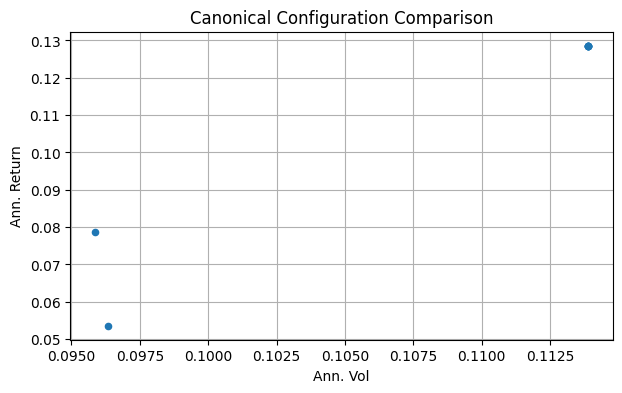

In [9]:
comparison_path = OUTPUT_DIR / 'config_comparison.csv'
if comparison_path.exists():
    comparison = pd.read_csv(comparison_path)
    display(comparison)
    comparison.plot.scatter(x='Ann. Vol', y='Ann. Return', figsize=(7, 4), grid=True)
    plt.title('Canonical Configuration Comparison')
    plt.show()
else:
    print('Config comparison not available for this output directory.')


In [10]:
selection_path = OUTPUT_DIR / 'submission_selection.json'
if selection_path.exists():
    display(pd.Series(json.loads(selection_path.read_text()), name='submission_selection'))
else:
    print('Submission-selection summary not available for this output directory.')


all_constraints_passed                             False
ann_return                                      0.128598
ann_vol                                         0.113883
beats_bm2_on_dsr                                   False
bm1_max_dd                                     -0.339145
bm2_dsr                                              1.0
bm2_max_dd                                     -0.352315
calmar                                          0.372252
decision_rule                 rule_3_smallest_mdd_breach
deflated_sharpe                                      1.0
display_name                                    Baseline
max_dd                                          -0.34546
mdd_breach_bps                                954.603446
mdd_improvement_bps_vs_bm2                     68.543525
mdd_improvement_bps_vs_saa                    2724.55858
n_tested_configurations                                6
pass_mdd                                           False
pass_return                    

## Attribution Decomposition

,comparison,grouping,component,total_contribution
0,saa_vs_bm2,asset,SPXT,-0.299263
1,saa_vs_bm2,asset,FTSE100,0.060220
2,saa_vs_bm2,asset,LBUSTRUU,0.020005
3,saa_vs_bm2,asset,BROAD_TIPS,0.025708
4,saa_vs_bm2,asset,B3REITT,-0.102238
5,saa_vs_bm2,asset,XAU,0.103283
6,saa_vs_bm2,asset,SILVER_FUT,0.038236
7,saa_vs_bm2,asset,NIKKEI225,0.012628
8,saa_vs_bm2,asset,CSI300_CHINA,0.116157
9,saa_vs_bm2,asset,BITCOIN,0.987954


,comparison,grouping,component,total_contribution
0,taa_vs_saa,asset,SPXT,0.004496
1,taa_vs_saa,asset,FTSE100,-0.045754
2,taa_vs_saa,asset,LBUSTRUU,-0.020298
3,taa_vs_saa,asset,BROAD_TIPS,-0.010953
4,taa_vs_saa,asset,B3REITT,-0.079503
5,taa_vs_saa,asset,XAU,-0.086817
6,taa_vs_saa,asset,SILVER_FUT,0.032295
7,taa_vs_saa,asset,NIKKEI225,0.004161
8,taa_vs_saa,asset,CSI300_CHINA,-0.159816
9,taa_vs_saa,asset,BITCOIN,0.565204


,variant_id,layer,baseline_sharpe,ablated_sharpe,marginal_oos_sharpe,baseline_turnover_cost,ablated_turnover_cost,turnover_cost_delta,baseline_ann_return,ablated_ann_return,ann_return_delta,baseline_max_drawdown,ablated_max_drawdown,notes
0,baseline,baseline,0.953598,0.953598,0.000000e+00,0.001454,0.001454,0.000000e+00,0.128598,0.128598,0.000000e+00,-0.34546,-0.34546,Existing baseline walk-forward run.
1,no_regime,regime,0.953598,0.953598,-1.265654e-14,0.001454,0.001454,-6.114900e-17,0.128598,0.128598,-1.776357e-15,-0.34546,-0.34546,Leave-one-out ablation for no_regime.
2,no_trend,trend,0.953598,0.953598,-1.265654e-14,0.001454,0.001454,-6.114900e-17,0.128598,0.128598,-1.776357e-15,-0.34546,-0.34546,Leave-one-out ablation for no_trend.
3,no_momo,momo,0.953598,0.953598,-1.265654e-14,0.001454,0.001454,-6.114900e-17,0.128598,0.128598,-1.776357e-15,-0.34546,-0.34546,Leave-one-out ablation for no_momo.


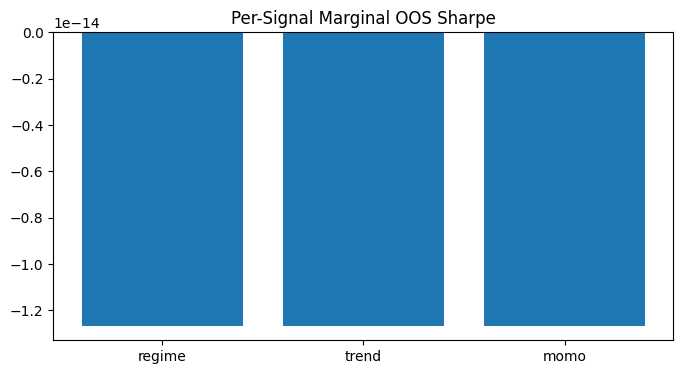

In [11]:
attr_saa = pd.read_csv(OUTPUT_DIR / 'attribution_saa_vs_bm2.csv')
attr_taa = pd.read_csv(OUTPUT_DIR / 'attribution_taa_vs_saa.csv')
attr_signal = pd.read_csv(OUTPUT_DIR / 'attribution_per_signal.csv')
display(attr_saa.head(20))
display(attr_taa.head(20))
display(attr_signal)
plot_df = attr_signal[attr_signal['layer'] != 'baseline']
plt.figure(figsize=(8, 4))
plt.bar(plot_df['layer'], plot_df['marginal_oos_sharpe'])
plt.title('Per-Signal Marginal OOS Sharpe')
plt.show()


## Turnover and Cost Profile

In [12]:
metrics = pd.read_csv(OUTPUT_DIR / 'portfolio_metrics.csv')
display(metrics[['portfolio','sharpe_rf_2pct','sortino_rf_2pct','calmar','turnover_pa','cost_drag_pa','hit_rate']].rename(columns={'sharpe_rf_2pct': 'Sharpe', 'sortino_rf_2pct': 'Sortino', 'calmar': 'Calmar'}))


,portfolio,Sharpe,Sortino,Calmar,turnover_pa,cost_drag_pa,hit_rate
0,BM1,0.348533,0.489344,0.157990,0.055414,0.000028,0.423767
1,BM2,0.611273,0.854395,0.223082,0.079175,0.000040,0.453159
2,SAA,0.473714,0.714989,0.142954,0.191534,0.000096,0.501783
3,SAA+TAA,0.953598,1.391321,0.372252,0.106232,0.000053,0.554348


## Trial Ledger

In [13]:
trial_ledger = pd.read_csv(Path('/Users/scottthomasswitzer/Desktop/FIN496FP/FIN496-Foundation-Project/TRIAL_LEDGER.csv'))
display(trial_ledger)
display(pd.read_csv(OUTPUT_DIR / 'dsr_summary.csv'))


,timestamp,variant_id,hmm_states,trend_window,momo_windows,signal_weights,ensemble_weights,cov_shrinkage,cv_folds,IS_sharpe,OOS_sharpe,DSR,notes,trial_id,timestamp_utc,use_timesfm,vol_budget,folds,start,end,ann_return,ann_vol,max_dd,sharpe,sortino,calmar
0,2026-04-19T20:08:07.817235+00:00,taa_baseline,3.0,200.0,1|3|6|12,"{""momo_scale"": 0.06, ""regime_scale"": 0.1, ""tim...","{""momo"": 0.2, ""regime"": 0.4, ""timesfm"": 0.2, ""...",0.70_sample_0.30_diag,5.0,NaN,1.106656,1.0,Baseline signal ensemble. Baseline run used --...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2026-04-19T20:08:07.817235+00:00,taa_no_regime,3.0,200.0,1|3|6|12,"{""momo_scale"": 0.06, ""regime_scale"": 0.1, ""tim...","{""momo"": 0.2, ""regime"": 0.0, ""timesfm"": 0.2, ""...",0.70_sample_0.30_diag,5.0,NaN,1.099294,1.0,Leave-one-out regime ablation.,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2026-04-19T20:08:07.817235+00:00,taa_no_trend,3.0,200.0,1|3|6|12,"{""momo_scale"": 0.06, ""regime_scale"": 0.1, ""tim...","{""momo"": 0.2, ""regime"": 0.4, ""timesfm"": 0.2, ""...",0.70_sample_0.30_diag,5.0,NaN,1.145087,1.0,Leave-one-out trend ablation.,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2026-04-19T20:08:07.817235+00:00,taa_no_momo,3.0,200.0,1|3|6|12,"{""momo_scale"": 0.06, ""regime_scale"": 0.1, ""tim...","{""momo"": 0.0, ""regime"": 0.4, ""timesfm"": 0.2, ""...",0.70_sample_0.30_diag,5.0,NaN,1.122124,1.0,Leave-one-out ADM ablation.,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2026-04-19T20:08:07.817235+00:00,saa_minimum_variance,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.562193,NaN,SAA method comparison row for minimum_variance.,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
90,2026-04-20T00:49:47.524981+00:00,saa_mean_variance,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.508683,NaN,SAA method comparison row for mean_variance.,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
91,2026-04-20T00:49:47.524981+00:00,saa_maximum_diversification,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.505045,NaN,SAA method comparison row for maximum_diversif...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
92,2026-04-20T00:49:47.524981+00:00,saa_inverse_vol,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.489743,NaN,SAA method comparison row for inverse_vol.,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
93,2026-04-20T00:49:47.524981+00:00,saa_risk_parity,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.473714,NaN,SAA method comparison row for risk_parity.,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,timestamp,n_taa_trials,baseline_variant_id,baseline_sharpe,baseline_dsr,timesfm_enabled
0,2026-04-20T00:49:47.524981+00:00,4,taa_baseline,0.953598,1.0,0
